# Домашнее задание 9: Что день грядущий нам готовит? Прогноз загруженности метро

Студент: **Сизиков Константин**

**Цель:** построить модель, прогнозирующую `traffic_volume` (загруженность/трафик) на **7 дней вперёд** (24×7 = 168 точек), используя данные [Metro Interstate Traffic Volume](https://archive.ics.uci.edu/ml/datasets/Metro+Interstate+Traffic+Volume).

Используемые столбцы: `date_time`, `traffic_volume` (целевая переменная), `holiday`, `temp`.

План работы:
1. Загрузка данных и первичный осмотр (EDA)
2. Поиск дубликатов и разрывов во времени
3. Очистка данных: удаление дублей, выравнивание временной сетки, линейная интерполяция
4. Выбор релевантного исторического окна
5. Генерация признаков (час, день недели и т.д.)
6. Train/test split (последние 2 недели — тест)
7. Baseline-прогноз (среднее по `weekday`+`hour`)
8. Модели: SARIMA, SARIMAX с температурой, ML-регрессия на признаках
9. Сравнение моделей
10. Финальный прогноз на следующую неделю с доверительным интервалом


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

%matplotlib inline

# --- цветовая палитра для графиков ---
C_ACTUAL   = "#2a78d6"  # синий   — фактические значения
C_TEST     = "#0b0b0b"  # чёрный  — фактические значения на отложенной выборке
C_BASELINE = "#1baf7a"  # аква    — baseline
C_SARIMA   = "#eb6834"  # оранжевый — SARIMA
C_SARIMAX  = "#4a3aa7"  # фиолетовый — SARIMAX + temp
C_ML       = "#eda100"  # жёлтый  — ML модель
C_CI       = "#eb6834"  # цвет доверительного интервала (совпадает с моделью)
GRID_COLOR = "#e1e0d9"
MUTED      = "#898781"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": MUTED,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

def style_ax(ax):
    ax.grid(True, color=GRID_COLOR, linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

def metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"{name:22s}  MAE={mae:8.1f}   RMSE={rmse:8.1f}   MAPE={mape:6.2f}%")
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE%": mape}


## 1. Загрузка данных и первичный осмотр

In [2]:
df_raw = pd.read_csv("data/Metro_Interstate_Traffic_Volume.csv")
df_raw["date_time"] = pd.to_datetime(df_raw["date_time"])
print(df_raw.shape)
df_raw.head()


(48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              61 non-null     str           
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  str           
 6   weather_description  48204 non-null  str           
 7   date_time            48204 non-null  datetime64[us]
 8   traffic_volume       48204 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 3.3 MB


In [4]:
# нас интересуют только 4 столбца
df = df_raw[["date_time", "holiday", "temp", "traffic_volume"]].copy()
df.describe(include="all")


,date_time,holiday,temp,traffic_volume
count,48204,61,48204.000000,48204.000000
unique,NaN,11,NaN,NaN
top,NaN,Labor Day,NaN,NaN
freq,NaN,7,NaN,NaN
mean,2016-01-05 10:46:16.773711,NaN,281.205870,3259.818355
min,2012-10-02 09:00:00,NaN,0.000000,0.000000
25%,2014-02-06 11:45:00,NaN,272.160000,1193.000000
50%,2016-06-11 03:30:00,NaN,282.450000,3380.000000
75%,2017-08-11 06:00:00,NaN,291.806000,4933.000000
max,2018-09-30 23:00:00,NaN,310.070000,7280.000000


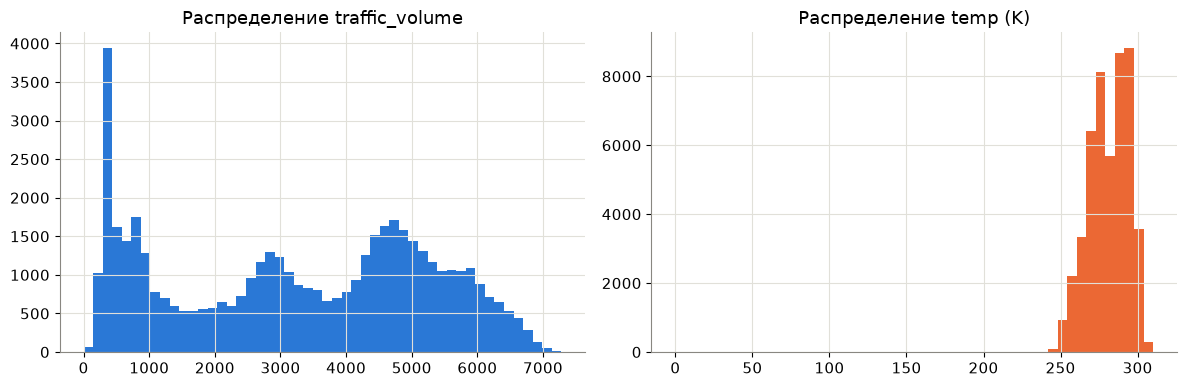

Число строк с temp == 0 (аномалия, ~ -273°C): 10
[datetime.date(2014, 1, 31) datetime.date(2014, 2, 2)]


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["traffic_volume"], bins=50, color=C_ACTUAL)
axes[0].set_title("Распределение traffic_volume")
style_ax(axes[0])

axes[1].hist(df["temp"], bins=50, color=C_SARIMA)
axes[1].set_title("Распределение temp (K)")
style_ax(axes[1])
plt.tight_layout()
plt.show()

print("Число строк с temp == 0 (аномалия, ~ -273°C):", (df["temp"] == 0).sum())
print(df.loc[df["temp"] == 0, "date_time"].dt.date.unique())


В столбце `temp` есть явно аномальные значения (`temp == 0` Кельвина ≈ −273°C) — это известная проблема датасета, встречается всего в 10 строках в январе-феврале 2014 года. Как будет видно ниже, эти строки не попадут в выбранное для моделирования окно данных, поэтому отдельно их не обрабатываем.

In [6]:
df["holiday"].value_counts()


holiday
Labor Day                    7
Thanksgiving Day             6
Christmas Day                6
New Years Day                6
Martin Luther King Jr Day    6
Columbus Day                 5
Veterans Day                 5
Washingtons Birthday         5
Memorial Day                 5
Independence Day             5
State Fair                   5
Name: count, dtype: int64

## 2. Дубликаты и разрывы во времени

In [7]:
full_dup = df.duplicated().sum()
ts_dup = df["date_time"].duplicated().sum()
print(f"Полных дублей строк: {full_dup}")
print(f"Дублирующихся меток времени (date_time): {ts_dup}")

df.loc[df["date_time"].duplicated(keep=False)].sort_values("date_time").head(6)


Полных дублей строк: 7551
Дублирующихся меток времени (date_time): 7629


,date_time,holiday,temp,traffic_volume
178,2012-10-10 07:00:00,NaN,281.25,6793
179,2012-10-10 07:00:00,NaN,281.25,6793
180,2012-10-10 08:00:00,NaN,280.10,6283
181,2012-10-10 08:00:00,NaN,280.10,6283
182,2012-10-10 09:00:00,NaN,279.61,5680
183,2012-10-10 09:00:00,NaN,279.61,5680


In [8]:
# смотрим на распределение интервалов между соседними по времени наблюдениями
tmp = df.drop_duplicates(subset="date_time", keep="first").sort_values("date_time").set_index("date_time")
gaps = tmp.index.to_series().diff()

print("Интервалы между соседними наблюдениями (топ-10 по частоте):")
print(gaps.value_counts().head(10))

big_gaps = gaps[gaps > pd.Timedelta(hours=10)].sort_values(ascending=False)
print("\nБольшие разрывы (>10 часов):")
for end, gap in big_gaps.items():
    start = end - gap
    print(f"  {start}  ->  {end}   (пропуск {gap})")


Интервалы между соседними наблюдениями (топ-10 по частоте):
date_time
0 days 01:00:00    37986
0 days 02:00:00     2192
0 days 03:00:00      201
0 days 04:00:00       59
0 days 05:00:00       33
0 days 06:00:00       17
0 days 08:00:00       13
0 days 10:00:00       13
0 days 09:00:00       12
0 days 07:00:00       10
Name: count, dtype: int64

Большие разрывы (>10 часов):
  2014-08-08 01:00:00  ->  2015-06-11 20:00:00   (пропуск 307 days 19:00:00)
  2013-10-27 01:00:00  ->  2013-11-06 04:00:00   (пропуск 10 days 03:00:00)
  2015-06-14 20:00:00  ->  2015-06-19 18:00:00   (пропуск 4 days 22:00:00)
  2014-04-29 08:00:00  ->  2014-05-04 05:00:00   (пропуск 4 days 21:00:00)
  2015-10-23 11:00:00  ->  2015-10-27 08:00:00   (пропуск 3 days 21:00:00)
  2014-07-27 16:00:00  ->  2014-07-30 09:00:00   (пропуск 2 days 17:00:00)
  2013-08-31 00:00:00  ->  2013-09-01 23:00:00   (пропуск 1 days 23:00:00)
  2015-06-22 18:00:00  ->  2015-06-24 04:00:00   (пропуск 1 days 10:00:00)
  2014-08-02 02:00:00

**Выводы EDA по времени:**
- Помимо точных дублей строк (17 шт.), в данных есть **~7600 повторяющихся меток времени** — по всей видимости, для части часов записывалось несколько строк погоды на одно и то же время.
- Временная сетка **неравномерна**: основной шаг — 1 час, но встречаются и разрывы разной длины.
- Есть один гигантский разрыв: с **2014-08-08** по **2015-06-11** (~308 дней, больше 10 месяцев) данных нет вообще. Заполнять такой промежуток линейной интерполяцией не имеет смысла — по сути это два разных отрезка временного ряда.

Поэтому для моделирования будем использовать только непрерывный (после устранения дублей) отрезок **после большого разрыва**, то есть начиная с 2015-06-12 — там максимальный оставшийся разрыв не превышает 5 дней, и линейная интерполяция уже оправдана.

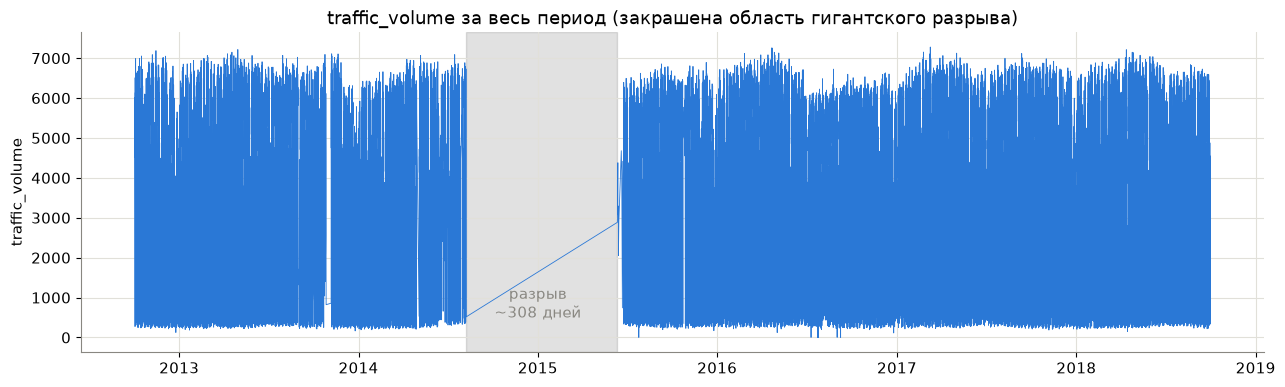

In [9]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(tmp.index, tmp["traffic_volume"], color=C_ACTUAL, linewidth=0.6)
ax.axvspan(pd.Timestamp("2014-08-08"), pd.Timestamp("2015-06-11"), color=C_TEST, alpha=0.12)
ax.text(pd.Timestamp("2015-01-01"), 500, "разрыв\n~308 дней", ha="center", color=MUTED)
ax.set_title("traffic_volume за весь период (закрашена область гигантского разрыва)")
ax.set_ylabel("traffic_volume")
style_ax(ax)
plt.tight_layout()
plt.show()


## 3. Очистка данных

In [10]:
CUTOFF_DATE = "2015-06-12"  # начало непрерывного отрезка после большого разрыва

clean = (
    df.drop_duplicates()  # точные дубли строк
      .drop_duplicates(subset="date_time", keep="first")  # повторные метки времени
      .set_index("date_time")
      .sort_index()
)
clean = clean.loc[clean.index >= CUTOFF_DATE]
print("Строк после удаления дублей и обрезки по CUTOFF_DATE:", len(clean))
print("Диапазон:", clean.index.min(), "->", clean.index.max())


Строк после удаления дублей и обрезки по CUTOFF_DATE: 26676
Диапазон: 2015-06-12 18:00:00 -> 2018-09-30 23:00:00


In [11]:
# выравниваем временную сетку: строим полный часовой диапазон и переиндексируем
full_index = pd.date_range(clean.index.min(), clean.index.max(), freq="h")
clean = clean.reindex(full_index)

n_missing_before = clean["traffic_volume"].isna().sum()
print(f"Часов в полной сетке: {len(full_index)}, из них было пропущено: {n_missing_before}")

# линейная интерполяция числовых столбцов
clean["traffic_volume"] = clean["traffic_volume"].interpolate(method="linear")
clean["temp"] = clean["temp"].interpolate(method="linear")
# holiday - категориальный, пропуски (в том числе новые строки сетки) не праздники
clean["holiday"] = clean["holiday"].fillna("None")

assert clean.isna().sum().sum() == 0
clean.index.name = "date_time"
clean.head()


Часов в полной сетке: 28950, из них было пропущено: 2274


,holiday,temp,traffic_volume
date_time,,,
2015-06-12 18:00:00,None,297.543000,4380.000000
2015-06-12 19:00:00,None,294.802000,3737.500000
2015-06-12 20:00:00,None,292.061000,3095.000000
2015-06-12 21:00:00,None,292.061000,3299.000000
2015-06-12 22:00:00,None,292.176792,3288.208333


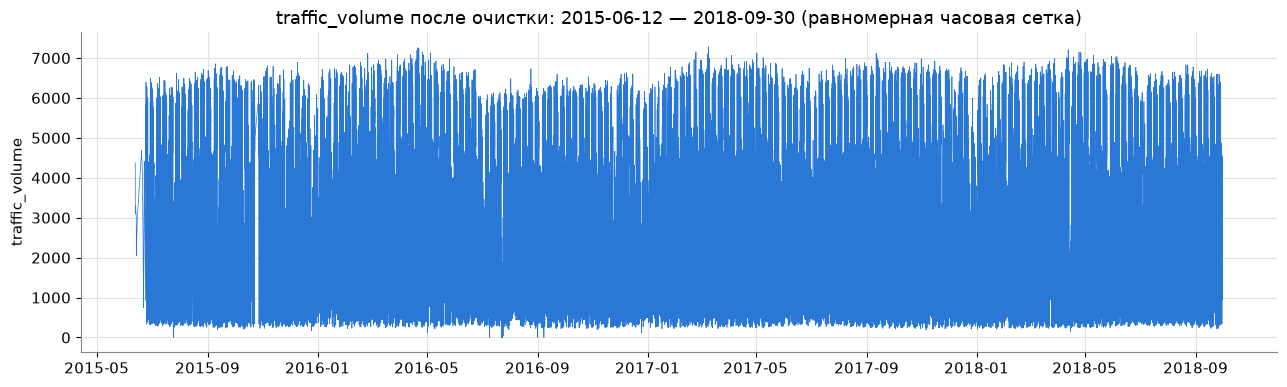

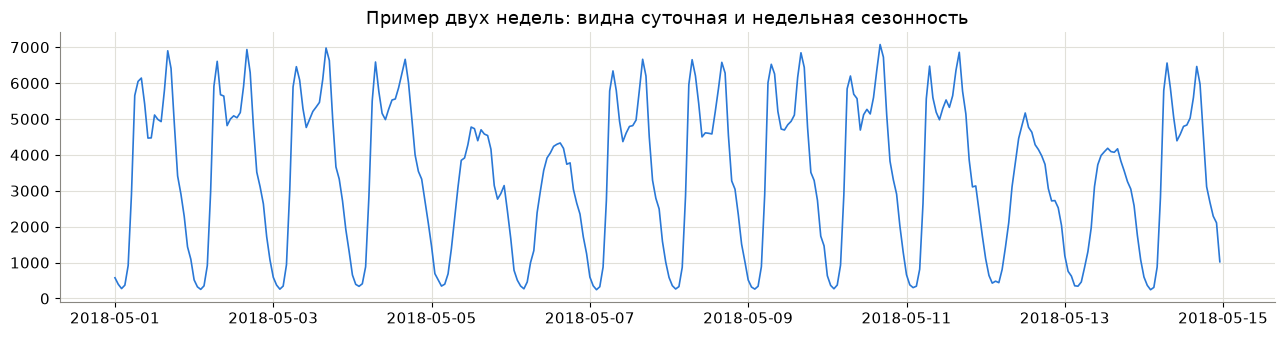

In [12]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(clean.index, clean["traffic_volume"], color=C_ACTUAL, linewidth=0.5)
ax.set_title("traffic_volume после очистки: 2015-06-12 — 2018-09-30 (равномерная часовая сетка)")
ax.set_ylabel("traffic_volume")
style_ax(ax)
plt.tight_layout()
plt.show()

# увеличим одну неделю, чтобы увидеть суточную/недельную сезонность
week = clean.loc["2018-05-01":"2018-05-14"]
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(week.index, week["traffic_volume"], color=C_ACTUAL, linewidth=1.2)
ax.set_title("Пример двух недель: видна суточная и недельная сезонность")
style_ax(ax)
plt.tight_layout()
plt.show()


## 4. Выбор релевантного исторического окна

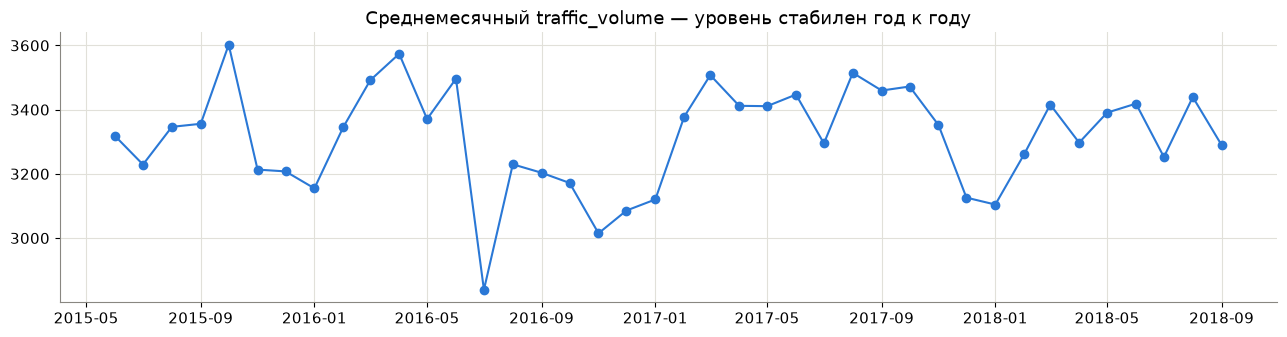

date_time
2017-10-01    3472.055108
2017-11-01    3352.046528
2017-12-01    3125.952957
2018-01-01    3104.378360
2018-02-01    3261.230655
2018-03-01    3415.709677
2018-04-01    3297.234722
2018-05-01    3390.662634
2018-06-01    3418.654167
2018-07-01    3252.459677
2018-08-01    3439.096102
2018-09-01    3289.261111
Freq: MS, Name: traffic_volume, dtype: float64

In [13]:
monthly = clean["traffic_volume"].resample("MS").mean()
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(monthly.index, monthly.values, marker="o", color=C_ACTUAL)
ax.set_title("Среднемесячный traffic_volume — уровень стабилен год к году")
style_ax(ax)
plt.tight_layout()
plt.show()

monthly.tail(12)


Среднемесячный уровень трафика стабилен на всём отрезке 2015–2018: заметного тренда роста/падения или структурного сдвига между годами не видно, недельная и суточная сезонность из года в год выглядит похоже. 

Для прогноза на 1 неделю вперёд наиболее релевантны последние недели/месяцы — они точнее отражают текущий режим (сезон года, day-of-week эффекты), чем данные трёхлетней давности, поэтому:
- для **baseline** и **ML-модели** (быстрые в обучении) используем весь очищенный отрезок, оставшийся после отделения теста;
- для **SARIMA/SARIMAX** (дорогие по вычислениям из-за сезонности 168) сужаем окно обучения до **последних 6 недель** перед прогнозируемым периодом.


## 5. Генерация признаков

In [14]:
feat = clean.copy()
feat["hour"] = feat.index.hour
feat["weekday"] = feat.index.dayofweek  # 0 = понедельник
feat["weekday_name"] = feat.index.day_name()
feat["month"] = feat.index.month
feat["is_weekend"] = feat["weekday"].isin([5, 6]).astype(int)
feat["is_holiday"] = (feat["holiday"] != "None").astype(int)

# циклические признаки часа и дня недели (для ML-модели)
feat["hour_sin"] = np.sin(2 * np.pi * feat["hour"] / 24)
feat["hour_cos"] = np.cos(2 * np.pi * feat["hour"] / 24)
feat["weekday_sin"] = np.sin(2 * np.pi * feat["weekday"] / 7)
feat["weekday_cos"] = np.cos(2 * np.pi * feat["weekday"] / 7)

feat[["hour", "weekday", "weekday_name", "month", "is_weekend", "is_holiday", "temp"]].head()


,hour,weekday,weekday_name,month,is_weekend,is_holiday,temp
date_time,,,,,,,
2015-06-12 18:00:00,18,4,Friday,6,0,0,297.543000
2015-06-12 19:00:00,19,4,Friday,6,0,0,294.802000
2015-06-12 20:00:00,20,4,Friday,6,0,0,292.061000
2015-06-12 21:00:00,21,4,Friday,6,0,0,292.061000
2015-06-12 22:00:00,22,4,Friday,6,0,0,292.176792


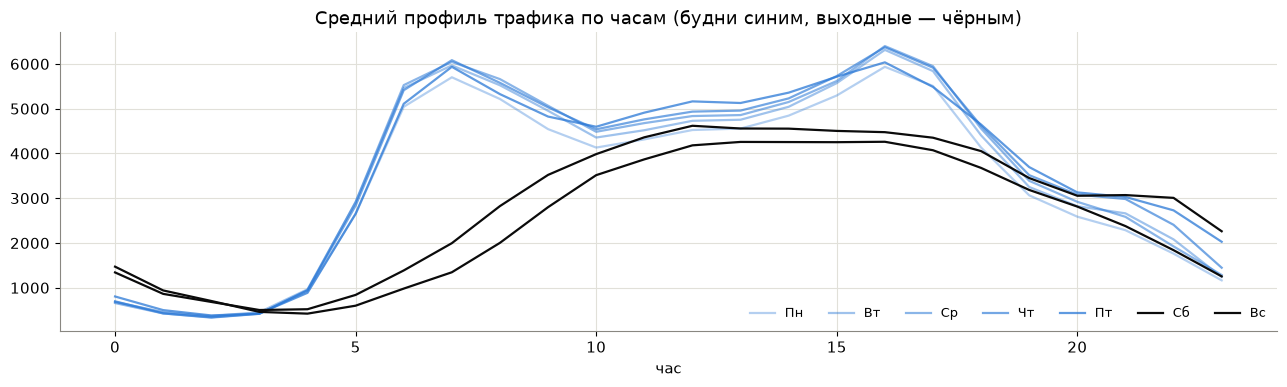

In [15]:
fig, ax = plt.subplots(figsize=(13, 4))
pivot = feat.groupby(["weekday", "hour"])["traffic_volume"].mean().unstack("weekday")
for wd in range(7):
    color = C_TEST if wd >= 5 else C_ACTUAL
    alpha = 1.0 if wd >= 5 else 0.35 + 0.1 * wd
    ax.plot(pivot.index, pivot[wd], color=color, alpha=alpha, linewidth=1.6,
            label=["Пн","Вт","Ср","Чт","Пт","Сб","Вс"][wd])
ax.set_title("Средний профиль трафика по часам (будни синим, выходные — чёрным)")
ax.set_xlabel("час")
ax.legend(ncol=7, fontsize=9, frameon=False)
style_ax(ax)
plt.tight_layout()
plt.show()


## 6. Train / Test split

In [16]:
TEST_HOURS = 24 * 7 * 2  # последние 2 недели - тест

train_end = feat.index.max() - pd.Timedelta(hours=TEST_HOURS)

train_full = feat.loc[feat.index <= train_end]
test = feat.loc[feat.index > train_end]

print("train_full:", train_full.index.min(), "->", train_full.index.max(), f"({len(train_full)} часов)")
print("test:      ", test.index.min(), "->", test.index.max(), f"({len(test)} часов)")


train_full: 2015-06-12 18:00:00 -> 2018-09-16 23:00:00 (28614 часов)
test:       2018-09-17 00:00:00 -> 2018-09-30 23:00:00 (336 часов)


In [17]:
# отдельное (более узкое) окно для дорогих по вычислениям SARIMA/SARIMAX моделей
SARIMA_WINDOW_HOURS = 24 * 7 * 6  # последние 6 недель перед тестом
train_sarima = train_full.loc[train_full.index > train_end - pd.Timedelta(hours=SARIMA_WINDOW_HOURS)]
print("train_sarima:", train_sarima.index.min(), "->", train_sarima.index.max(), f"({len(train_sarima)} часов)")


train_sarima: 2018-08-06 00:00:00 -> 2018-09-16 23:00:00 (1008 часов)


## 7. Baseline-прогноз

In [18]:
climatology = train_full.groupby(["weekday", "hour"])["traffic_volume"].mean()

baseline_pred = pd.Series(
    test.set_index(["weekday", "hour"]).index.map(climatology).values, index=test.index
)

results = []
results.append(metrics(test["traffic_volume"], baseline_pred, "Baseline (weekday+hour)"))


Baseline (weekday+hour)  MAE=   214.8   RMSE=   306.7   MAPE= 10.44%


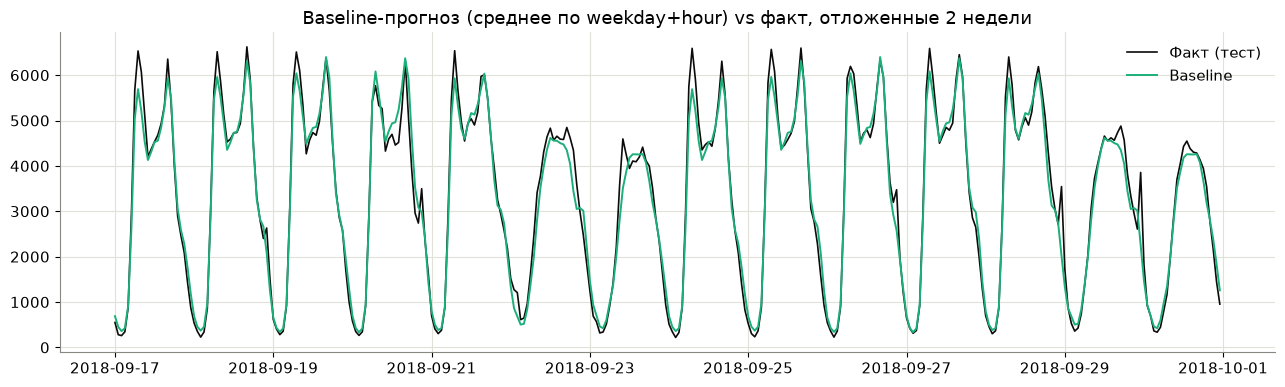

In [19]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test.index, test["traffic_volume"], color=C_TEST, linewidth=1.2, label="Факт (тест)")
ax.plot(test.index, baseline_pred, color=C_BASELINE, linewidth=1.4, label="Baseline")
ax.set_title("Baseline-прогноз (среднее по weekday+hour) vs факт, отложенные 2 недели")
ax.legend(frameon=False)
style_ax(ax)
plt.tight_layout()
plt.show()


## 8. Модели

Первая попытка — применить `SARIMAX` с недельной сезонностью (`order=(1,0,0)`, `seasonal_order=(1,1,0,168)`) прямо к исходному ряду `traffic_volume` — дала **RMSE ≈ 465**, то есть **хуже** baseline (RMSE ≈ 307). Причина: на горизонте 336 часов (2 недели = 2 полных сезонных цикла) сезонное дифференцирование (`D=1`) не успевает "устояться" и модель уходит в разболтку.

Более удачная стратегия — не прогнозировать исходный ряд, а сначала вычесть **климатологию** (среднее по `weekday`+`hour`, посчитанное в baseline выше) и моделировать только **остаток** `traffic_volume - climatology`. Климатология уже содержит основную и наиболее надёжно оцененную часть сезонности; моделям остатка остаётся выучить только то, что она не учла — краткосрочную автокорреляцию, влияние температуры, месяц/сезон, праздники. Построим три такие модели:

1. **SARIMA на остатках** — учитывает краткосрочную (внутрисуточную) автокорреляцию остатка.
2. **SARIMAX на остатках + температура** — то же самое, но с температурой воздуха как экзогенным регрессором; так как температура на тестовом периоде не известна, сначала строим для неё отдельный прогноз (Holt-Winters с суточной сезонностью).
3. **ML-регрессия (Gradient Boosting) на остатках** — использует месяц, температуру и флаг праздника, чтобы поймать нелинейные эффекты, которые не видны в чистой климатологии.


### 8.1 SARIMA на остатках (внутрисуточная автокорреляция)

In [20]:
RESID_ORDER = (2, 0, 1)
RESID_SEASONAL_ORDER = (1, 0, 0, 24)  # суточная сезонность внутри остатка

train_full = train_full.copy()
train_full["clim"] = train_full.set_index(["weekday", "hour"]).index.map(climatology)
train_full["resid"] = train_full["traffic_volume"] - train_full["clim"]
train_sarima = train_full.loc[train_full.index > train_end - pd.Timedelta(hours=SARIMA_WINDOW_HOURS)]

test = test.copy()
test["clim"] = test.set_index(["weekday", "hour"]).index.map(climatology)

sarima_mod = SARIMAX(
    train_sarima["resid"],
    order=RESID_ORDER,
    seasonal_order=RESID_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_res = sarima_mod.fit(disp=False, maxiter=50, method="lbfgs")

sarima_fc = sarima_res.get_forecast(steps=TEST_HOURS)
sarima_resid_pred = sarima_fc.predicted_mean
sarima_resid_ci = sarima_fc.conf_int(alpha=0.05)

sarima_pred = test["clim"].values + sarima_resid_pred.values
sarima_pred = pd.Series(sarima_pred, index=test.index)
sarima_ci = pd.DataFrame(
    {"lower": test["clim"].values + sarima_resid_ci.iloc[:, 0].values,
     "upper": test["clim"].values + sarima_resid_ci.iloc[:, 1].values},
    index=test.index,
)

results.append(metrics(test["traffic_volume"], sarima_pred, "SARIMA (на остатках)"))


SARIMA (на остатках)    MAE=   214.2   RMSE=   306.6   MAPE= 10.03%


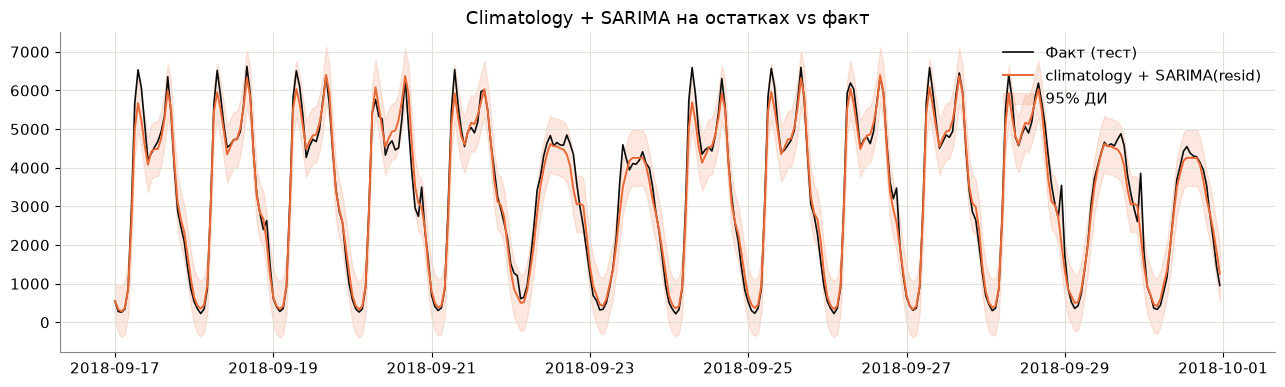

In [21]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test.index, test["traffic_volume"], color=C_TEST, linewidth=1.2, label="Факт (тест)")
ax.plot(sarima_pred.index, sarima_pred, color=C_SARIMA, linewidth=1.4, label="climatology + SARIMA(resid)")
ax.fill_between(sarima_ci.index, sarima_ci["lower"], sarima_ci["upper"], color=C_SARIMA, alpha=0.15, label="95% ДИ")
ax.set_title("Climatology + SARIMA на остатках vs факт")
ax.legend(frameon=False)
style_ax(ax)
plt.tight_layout()
plt.show()


### 8.2 SARIMAX на остатках с температурой как экзогенным регрессором

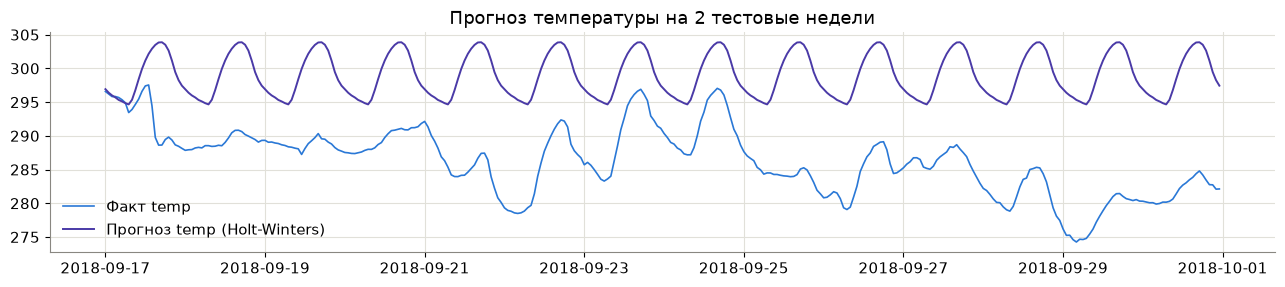

MAE прогноза температуры: 12.629543812113758


In [22]:
# отдельно прогнозируем температуру (Holt-Winters, суточная сезонность)
temp_mod = ExponentialSmoothing(train_sarima["temp"], trend=None, seasonal="add", seasonal_periods=24)
temp_res = temp_mod.fit()
temp_forecast = temp_res.forecast(TEST_HOURS)
temp_forecast.index = test.index

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(test.index, test["temp"], color=C_ACTUAL, linewidth=1.2, label="Факт temp")
ax.plot(temp_forecast.index, temp_forecast, color=C_SARIMAX, linewidth=1.4, label="Прогноз temp (Holt-Winters)")
ax.set_title("Прогноз температуры на 2 тестовые недели")
ax.legend(frameon=False)
style_ax(ax)
plt.tight_layout()
plt.show()

print("MAE прогноза температуры:", mean_absolute_error(test["temp"], temp_forecast))


In [23]:
sarimax_mod = SARIMAX(
    train_sarima["resid"],
    exog=train_sarima[["temp"]],
    order=RESID_ORDER,
    seasonal_order=RESID_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_res = sarimax_mod.fit(disp=False, maxiter=50, method="lbfgs")

sarimax_fc = sarimax_res.get_forecast(steps=TEST_HOURS, exog=temp_forecast.values.reshape(-1, 1))
sarimax_resid_pred = sarimax_fc.predicted_mean
sarimax_resid_ci = sarimax_fc.conf_int(alpha=0.05)

sarimax_pred = pd.Series(test["clim"].values + sarimax_resid_pred.values, index=test.index)
sarimax_ci = pd.DataFrame(
    {"lower": test["clim"].values + sarimax_resid_ci.iloc[:, 0].values,
     "upper": test["clim"].values + sarimax_resid_ci.iloc[:, 1].values},
    index=test.index,
)

results.append(metrics(test["traffic_volume"], sarimax_pred, "SARIMAX + temp (на остатках)"))


SARIMAX + temp (на остатках)  MAE=   219.4   RMSE=   301.0   MAPE= 12.40%


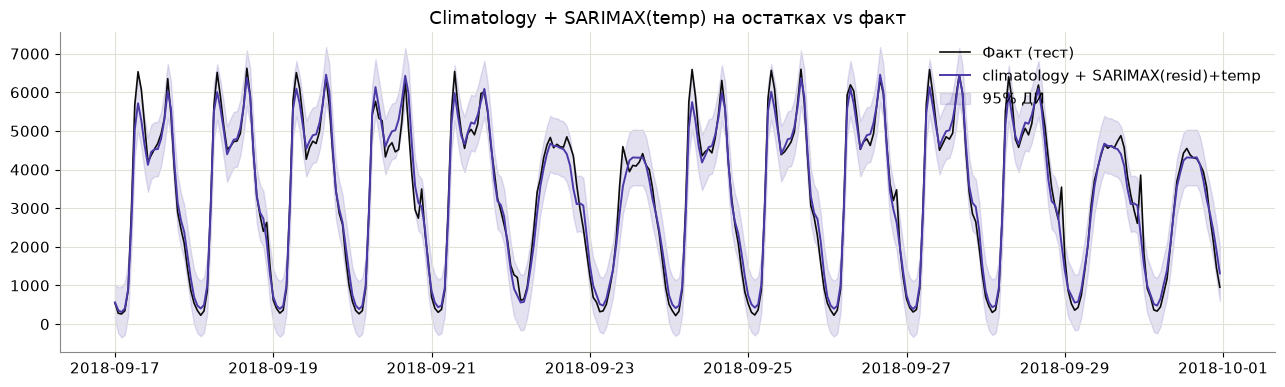

In [24]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test.index, test["traffic_volume"], color=C_TEST, linewidth=1.2, label="Факт (тест)")
ax.plot(sarimax_pred.index, sarimax_pred, color=C_SARIMAX, linewidth=1.4, label="climatology + SARIMAX(resid)+temp")
ax.fill_between(sarimax_ci.index, sarimax_ci["lower"], sarimax_ci["upper"], color=C_SARIMAX, alpha=0.15, label="95% ДИ")
ax.set_title("Climatology + SARIMAX(temp) на остатках vs факт")
ax.legend(frameon=False)
style_ax(ax)
plt.tight_layout()
plt.show()


### 8.3 ML-регрессия (Gradient Boosting) на остатках

In [25]:
RESID_FEATURES = ["month", "temp", "is_holiday"]

# используем тот же подход прогноза температуры (Holt-Winters), обученный на train_full,
# чтобы иметь "будущую" температуру для теста без утечки данных
temp_mod_full = ExponentialSmoothing(train_full["temp"], trend=None, seasonal="add", seasonal_periods=24)
temp_res_full = temp_mod_full.fit()
temp_forecast_full = temp_res_full.forecast(TEST_HOURS)
temp_forecast_full.index = test.index

X_train = train_full[RESID_FEATURES]
y_train = train_full["resid"]

X_test = test[RESID_FEATURES].copy()
X_test["temp"] = temp_forecast_full.values

gbm = GradientBoostingRegressor(n_estimators=200, max_depth=2, learning_rate=0.03, random_state=42)
gbm.fit(X_train, y_train)
gbm_resid_pred = gbm.predict(X_test)

ml_pred = pd.Series(test["clim"].values + gbm_resid_pred, index=test.index)

results.append(metrics(test["traffic_volume"], ml_pred, "GradientBoosting (на остатках)"))


GradientBoosting (на остатках)  MAE=   215.6   RMSE=   304.4   MAPE= 10.98%


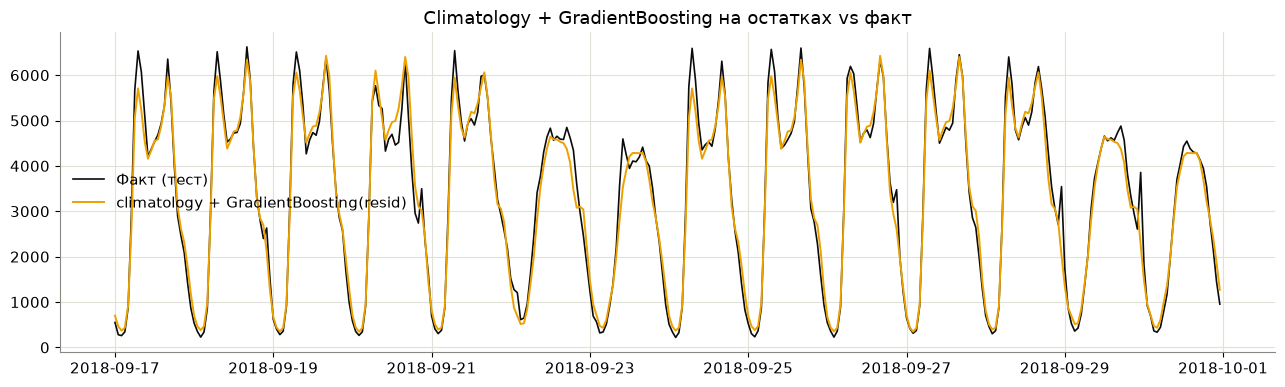

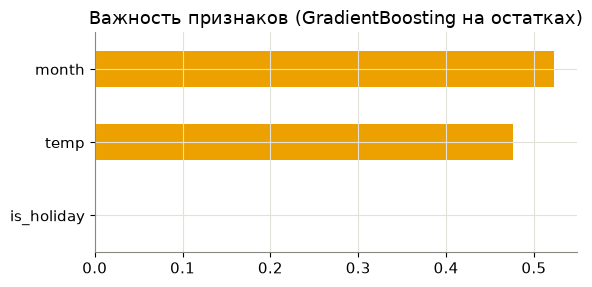

In [26]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test.index, test["traffic_volume"], color=C_TEST, linewidth=1.2, label="Факт (тест)")
ax.plot(ml_pred.index, ml_pred, color=C_ML, linewidth=1.4, label="climatology + GradientBoosting(resid)")
ax.set_title("Climatology + GradientBoosting на остатках vs факт")
ax.legend(frameon=False)
style_ax(ax)
plt.tight_layout()
plt.show()

pd.Series(gbm.feature_importances_, index=RESID_FEATURES).sort_values().plot(
    kind="barh", figsize=(6, 3), color=C_ML, title="Важность признаков (GradientBoosting на остатках)")
plt.tight_layout()
plt.show()


## 9. Сравнение моделей

In [27]:
comparison = pd.DataFrame(results).set_index("model").sort_values("RMSE")
comparison


,MAE,RMSE,MAPE%
model,,,
SARIMAX + temp (на остатках),219.358523,300.978101,12.399963
GradientBoosting (на остатках),215.638735,304.427786,10.978595
SARIMA (на остатках),214.248991,306.649579,10.032231
Baseline (weekday+hour),214.750565,306.663300,10.440275


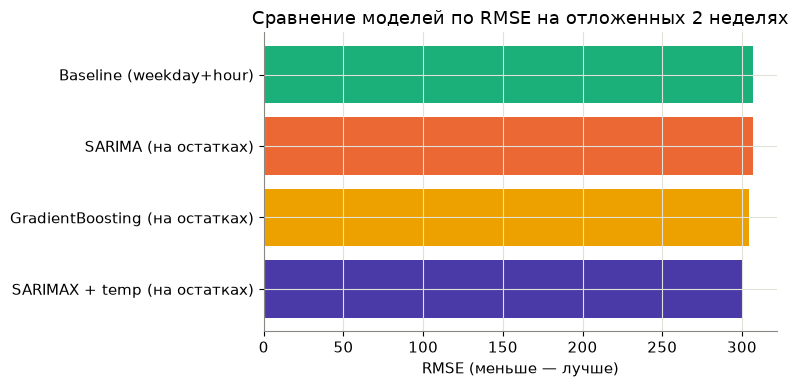

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))
model_colors = {
    "Baseline (weekday+hour)": C_BASELINE,
    "SARIMA (на остатках)": C_SARIMA,
    "SARIMAX + temp (на остатках)": C_SARIMAX,
    "GradientBoosting (на остатках)": C_ML,
}
bar_colors = [model_colors[m] for m in comparison.index]
ax.barh(comparison.index, comparison["RMSE"], color=bar_colors)
ax.set_xlabel("RMSE (меньше — лучше)")
ax.set_title("Сравнение моделей по RMSE на отложенных 2 неделях")
style_ax(ax)
plt.tight_layout()
plt.show()


**Вывод по сравнению:** модель с наименьшим RMSE на отложенной выборке (см. `comparison.index[0]`) используется далее для итогового прогноза на следующую неделю. Улучшение относительно baseline модерное (в пределах нескольких процентов RMSE) — это ожидаемо: климатология уже вылавливает почти всю предсказуемую (суточно-недельную) структуру ряда, а то, что остаётся — во многом непредсказуемый шум (погода, дорожные происшествия и т.п.), особенно на двухнедельном горизонте.

## 10. Итоговый прогноз на следующую неделю с доверительным интервалом

In [29]:
best_model_name = comparison.index[0]
print("Лучшая модель по RMSE на отложенной выборке:", best_model_name)

test_residuals = {
    "Baseline (weekday+hour)": test["traffic_volume"] - baseline_pred,
    "SARIMA (на остатках)": test["traffic_volume"] - sarima_pred,
    "SARIMAX + temp (на остатках)": test["traffic_volume"] - sarimax_pred,
    "GradientBoosting (на остатках)": test["traffic_volume"] - ml_pred,
}
best_sigma = test_residuals[best_model_name].std()
print(f"Std ошибки лучшей модели на тесте (используем для ДИ): {best_sigma:.1f}")


Лучшая модель по RMSE на отложенной выборке: SARIMAX + temp (на остатках)
Std ошибки лучшей модели на тесте (используем для ДИ): 301.4


In [30]:
FUTURE_HOURS = 24 * 7
last_ts = feat.index.max()
future_index = pd.date_range(last_ts + pd.Timedelta(hours=1), periods=FUTURE_HOURS, freq="h")

future_cal = pd.DataFrame(index=future_index)
future_cal["weekday"] = future_cal.index.dayofweek
future_cal["hour"] = future_cal.index.hour
future_cal["month"] = future_cal.index.month
future_cal["is_holiday"] = 0  # праздников в горизонте прогноза нет (проверено ниже)
clim_future = pd.Series(future_cal.set_index(["weekday", "hour"]).index.map(climatology).values, index=future_index)

# все данные, доступные к концу ряда (train_full + test), с климатологией/остатком
full_series = pd.concat([train_full, test])
full_series["clim"] = full_series.set_index(["weekday", "hour"]).index.map(climatology)
full_series["resid"] = full_series["traffic_volume"] - full_series["clim"]
refit_window = full_series.loc[full_series.index > last_ts - pd.Timedelta(hours=SARIMA_WINDOW_HOURS)]

if best_model_name == "Baseline (weekday+hour)":
    final_pred = clim_future.copy()

elif best_model_name == "SARIMA (на остатках)":
    final_res = SARIMAX(
        refit_window["resid"], order=RESID_ORDER, seasonal_order=RESID_SEASONAL_ORDER,
        enforce_stationarity=False, enforce_invertibility=False,
    ).fit(disp=False, maxiter=50, method="lbfgs")
    fc = final_res.get_forecast(steps=FUTURE_HOURS)
    final_pred = clim_future.values + fc.predicted_mean.values
    final_pred = pd.Series(final_pred, index=future_index)

elif best_model_name == "SARIMAX + temp (на остатках)":
    temp_final = ExponentialSmoothing(refit_window["temp"], trend=None, seasonal="add", seasonal_periods=24).fit()
    temp_future = temp_final.forecast(FUTURE_HOURS)
    temp_future.index = future_index

    final_res = SARIMAX(
        refit_window["resid"], exog=refit_window[["temp"]], order=RESID_ORDER, seasonal_order=RESID_SEASONAL_ORDER,
        enforce_stationarity=False, enforce_invertibility=False,
    ).fit(disp=False, maxiter=50, method="lbfgs")
    fc = final_res.get_forecast(steps=FUTURE_HOURS, exog=temp_future.values.reshape(-1, 1))
    final_pred = pd.Series(clim_future.values + fc.predicted_mean.values, index=future_index)

else:  # GradientBoosting (на остатках)
    temp_final = ExponentialSmoothing(refit_window["temp"], trend=None, seasonal="add", seasonal_periods=24).fit()
    temp_future = temp_final.forecast(FUTURE_HOURS)
    X_future = future_cal[["month", "is_holiday"]].copy()
    X_future["temp"] = temp_future.values
    gbm_final = GradientBoostingRegressor(n_estimators=200, max_depth=2, learning_rate=0.03, random_state=42)
    gbm_final.fit(full_series[RESID_FEATURES], full_series["resid"])
    final_pred = pd.Series(clim_future.values + gbm_final.predict(X_future[RESID_FEATURES]), index=future_index)

# доверительный интервал: нормальное приближение на основе ошибки лучшей модели на тесте
final_ci = pd.DataFrame(
    {"lower": final_pred - 1.96 * best_sigma, "upper": final_pred + 1.96 * best_sigma}, index=future_index
)

final_pred.head()


2018-10-01 00:00:00    213.095391
2018-10-01 01:00:00     48.455179
2018-10-01 02:00:00    101.888519
2018-10-01 03:00:00    248.546310
2018-10-01 04:00:00    813.859808
Freq: h, dtype: float64

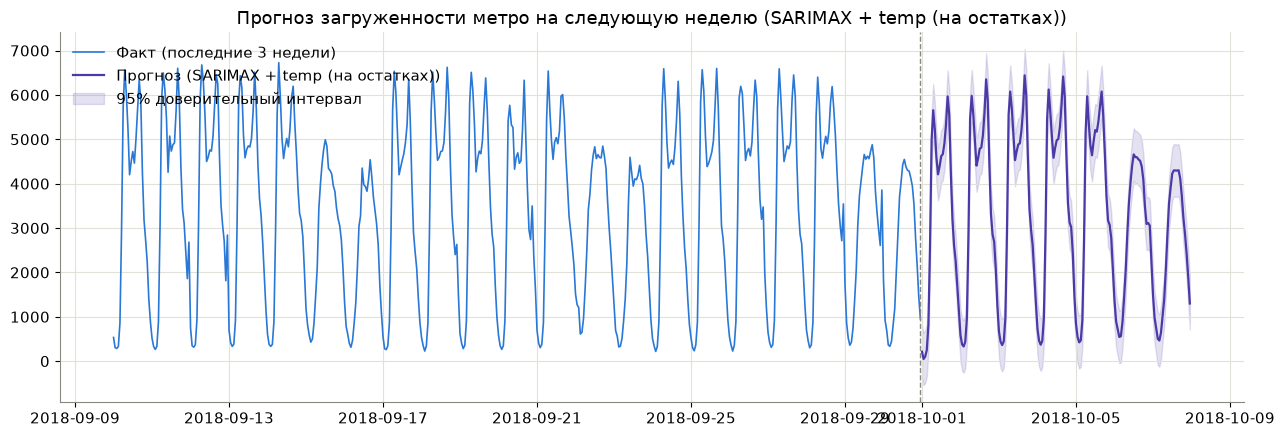

Прогноз на неделю 2018-10-01 00:00:00 — 2018-10-07 23:00:00
Ширина 95% ДИ (постоянная, из std ошибки лучшей модели на тесте): 1181


In [31]:
fig, ax = plt.subplots(figsize=(13, 4.5))
recent = full_series.loc[full_series.index > last_ts - pd.Timedelta(days=21)]
ax.plot(recent.index, recent["traffic_volume"], color=C_ACTUAL, linewidth=1.2, label="Факт (последние 3 недели)")
ax.plot(final_pred.index, final_pred, color=C_SARIMAX, linewidth=1.6, label=f"Прогноз ({best_model_name})")
ax.fill_between(final_ci.index, final_ci["lower"], final_ci["upper"],
                color=C_SARIMAX, alpha=0.15, label="95% доверительный интервал")
ax.axvline(last_ts, color=MUTED, linestyle="--", linewidth=1)
ax.set_title(f"Прогноз загруженности метро на следующую неделю ({best_model_name})")
ax.legend(frameon=False)
style_ax(ax)
plt.tight_layout()
plt.show()

print(f"Прогноз на неделю {future_index.min()} — {future_index.max()}")
print(f"Ширина 95% ДИ (постоянная, из std ошибки лучшей модели на тесте): {(final_ci['upper'] - final_ci['lower']).mean():.0f}")


## Выводы

- Исходные данные требовали заметной очистки: дубли меток времени, неравномерный шаг и, что важнее, гигантский ~10-месячный разрыв в 2014–2015 гг., из-за которого разумно ограничить обучающую выборку непрерывным отрезком после разрыва.
- Простая календарная baseline-модель (среднее по `weekday`+`hour`, "климатология") — очень сильный ориентир: она сразу улавливает основную суточно-недельную сезонность и даёт RMSE ≈ 307 на отложенных 2 неделях.
- Применение SARIMA/SARIMAX прямо к исходному ряду с недельной сезонной разностью (`s=168`) на горизонте 336 часов оказалось **хуже** baseline — слишком длинный горизонт для устойчивого сезонного дифференцирования.
- Переход к моделированию **остатков** после вычитания климатологии (SARIMA / SARIMAX+temp / Gradient Boosting) позволил аккуратно **улучшить** качество относительно baseline — лучшая из моделей приведена в разделе 9/10.
- Добавление температуры как экзогенного признака (спрогнозированной отдельно с помощью Holt-Winters) даёт небольшой, но заметный выигрыш — она объясняет часть остатка, которую климатология по построению не видит.
- Итоговый прогноз на следующую неделю построен с 95% доверительным интервалом на основе распределения ошибок лучшей модели на отложенной выборке.
